Analysis by Alex Rytz, Leonard Hahnloser and Julius Langhoff
Last updated at: 01.06.26

## Refraction

### Snell's Law
Snell's law relates the angle of incidence $\alpha$ and the angle of refraction $\beta$ through

$$n_A \sin(\alpha) = n \sin(\beta).$$

Since the refractive index $n_A$ of air is approximately 1, this becomes

$$\sin(\alpha) = n \sin(\beta),$$

where $n$ is the refractive index of the glass prism relative to air.

#### Graphing $\sin\alpha$ vs. $\sin\beta$
If we plot $y = \sin(\alpha)$ against $x = \sin(\beta)$, the formula becomes
$$y = n x,$$
We thus expect to get a linear function whose slope ($y' = (n x)'$) is the refractive index ($(n x)' = n$).

The uncertainty of the sin values is obtained by Gaussian error propagation,

$$d(\sin\theta) = |\cos\theta| \, d\theta,$$

with the angular uncertainty expressed in radians.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.odr import Model, ODR, RealData

# Enter the measured angles in degrees.
alpha = np.array([60, 39, 21, 7, 13.5, 32.5, 47.5, 27])  # angle of incidence
beta = np.array([37, 26, 14, 5, 11.5, 21, 31, 19])   # angle of refraction

dalpha = 2.0  # uncertainty of alpha in degrees
dbeta = 2.0   # uncertainty of beta in degrees

def require_data(*arrays):
    if any(np.size(arr) == 0 for arr in arrays):
        raise ValueError('Enter your measured data in the arrays before running the analysis cells.')

def line_through_origin(x, m):
    return m * x

def odr_line_through_origin(beta, x):
    return beta[0] * x

def constant_model(x, c):
    x = np.asarray(x)
    return np.full_like(x, c, dtype=float)

def displacement_model(alpha_deg, n, width_cm):
    alpha_rad = np.deg2rad(alpha_deg)
    beta_rad = np.arcsin(np.clip(np.sin(alpha_rad) / n, -1, 1))
    return width_cm * np.sin(alpha_rad - beta_rad) / np.cos(beta_rad)

require_data(alpha, beta)

if alpha.shape != beta.shape:
    raise ValueError('alpha and beta must have the same length.')

alpha_rad = np.deg2rad(alpha)
beta_rad = np.deg2rad(beta)
dalpha_rad = np.deg2rad(dalpha)
dbeta_rad = np.deg2rad(dbeta)

sin_alpha = np.sin(alpha_rad)
sin_beta = np.sin(beta_rad)
dsin_alpha = np.abs(np.cos(alpha_rad)) * dalpha_rad
dsin_beta = np.abs(np.cos(beta_rad)) * dbeta_rad

n_point = sin_alpha / sin_beta
dn_point = n_point * np.sqrt((dsin_alpha / sin_alpha)**2 + (dsin_beta / sin_beta)**2)


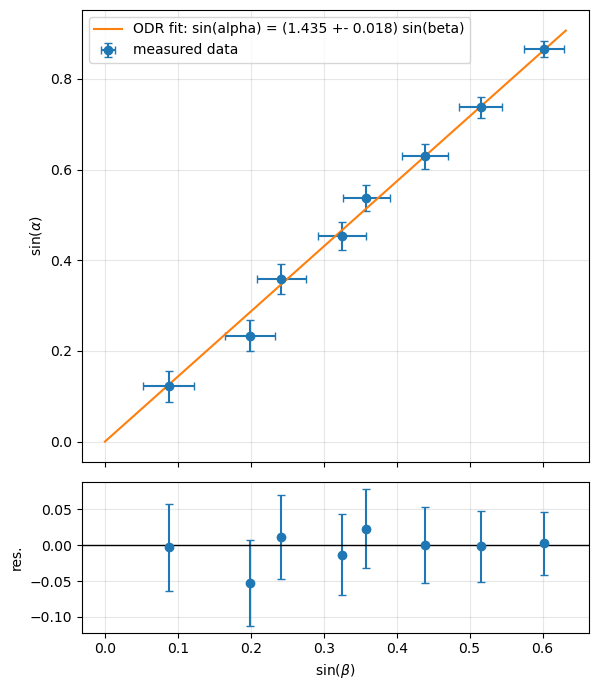

In [2]:
sin_data = RealData(sin_beta, sin_alpha, sx=dsin_beta, sy=dsin_alpha)
sin_model = Model(odr_line_through_origin)
sin_odr = ODR(sin_data, sin_model, beta0=[1.5])
sin_output = sin_odr.run()

n_sin = sin_output.beta[0]
dn_sin = sin_output.sd_beta[0]

sin_beta_fit = np.linspace(0, 1.05 * np.max(sin_beta), 300)
sin_alpha_fit = line_through_origin(sin_beta_fit, n_sin)
residuals_sin = sin_alpha - line_through_origin(sin_beta, n_sin)
dresiduals_sin = np.sqrt(dsin_alpha**2 + (n_sin * dsin_beta)**2)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(sin_beta, sin_alpha, xerr=dsin_beta, yerr=dsin_alpha, fmt='o', capsize=3, label='measured data')
ax.plot(sin_beta_fit, sin_alpha_fit, label=f'ODR fit: sin(alpha) = ({n_sin:.3f} +- {dn_sin:.3f}) sin(beta)')
ax.set_ylabel(r'$\sin(\alpha)$')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(sin_beta, residuals_sin, yerr=dresiduals_sin, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\sin(\beta)$')
ax_res.set_ylabel('res.')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Refractive Index
From Snell's law in the form $\sin(\alpha) = n \sin(\beta)$, the slope of the graph $\sin(\alpha)$ vs. $\sin(\beta)$ is directly equal to the refractive index $n$ of the material relative to air. We expect a value larger than 1 as the prism is an optically denser medium.

In [3]:
print(f'Refractive index: n = {n_sin:.3f} +- {dn_sin:.3f}')

Refractive index: n = 1.435 +- 0.018


#### Fit Discussion
Examining the residual plot, we see that all measurements are within the error margins / all error bars overlap with the linear fit. We used a rather pessimistic uncertainty of 2°, as measuring these angles was quite hard. This indicates measurements consistent with the theory and a good fit to the data.
The calculated refractive index also fits our expectations.

#### Graphing $\beta$ vs. $\alpha$

From Snell's law with air outside the prism,

$$\sin(\alpha) = n\sin(\beta),$$

we get

$$\beta(\alpha) = \arcsin\!\left(\frac{\sin(\alpha)}{n}\right).$$

This is in contrast to the sin graphs from above not linear.

Because the prism is optically denser than air, one expects $n>1$ and therefore $\beta < \alpha$ for all measured points. The graph should therefore show a rising curve below the line $\beta = \alpha$.

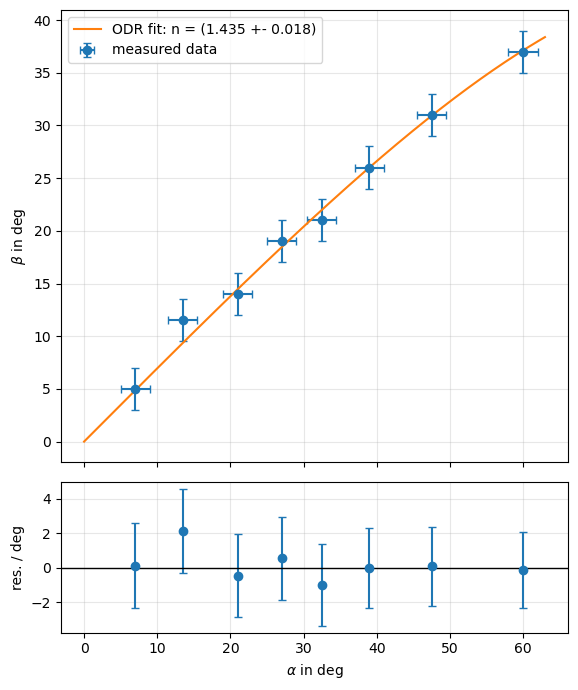

In [4]:
def beta_from_alpha_model(params, alpha_deg):
    n = params[0]
    alpha_rad = np.deg2rad(alpha_deg)
    beta_rad = np.arcsin(np.clip(np.sin(alpha_rad) / n, -1, 1))
    return np.rad2deg(beta_rad)

alpha_sigma = np.full_like(alpha, dalpha, dtype=float)
beta_sigma = np.full_like(beta, dbeta, dtype=float)

# use an odr instead of curve-fit for 2d uncertainties
beta_data = RealData(alpha, beta, sx=alpha_sigma, sy=beta_sigma)
beta_model = Model(beta_from_alpha_model)
beta_odr = ODR(beta_data, beta_model, beta0=[n_sin])
beta_output = beta_odr.run()

n_beta = beta_output.beta[0]
dn_beta = beta_output.sd_beta[0]

alpha_fit = np.linspace(0, 1.05 * np.max(alpha), 300)
beta_fit = beta_from_alpha_model([n_beta], alpha_fit)
residuals_beta = beta - beta_from_alpha_model([n_beta], alpha)

h_alpha = max(dalpha, 1e-6)
dbeta_dalpha = (
    beta_from_alpha_model([n_beta], alpha + h_alpha) - beta_from_alpha_model([n_beta], alpha - h_alpha)
) / (2 * h_alpha)
dresiduals_beta = np.sqrt(beta_sigma**2 + (dbeta_dalpha * alpha_sigma)**2)

fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(alpha, beta, xerr=dalpha, yerr=dbeta, fmt='o', capsize=3, label='measured data')
ax.plot(alpha_fit, beta_fit, label=f'ODR fit: n = ({n_beta:.3f} +- {dn_beta:.3f})')
ax.set_ylabel(r'$\beta$ in deg')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(alpha, residuals_beta, yerr=dresiduals_beta, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\alpha$ in deg')
ax_res.set_ylabel('res. / deg')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Refractive Index
In this fit, the refractive index $n$ is itself the fit parameter of the model

$$\beta(\alpha) = \arcsin\!\left(\frac{\sin(\alpha)}{n}\right).$$

The value returned by the fit therefore directly gives the refractive index of the prism relative to air. Its uncertainty is obtained from the fit uncertainty of the parameter $n$.



In [5]:
print(f'Refractive index from the beta-vs-alpha fit: n = {n_beta:.3f} +- {dn_beta:.3f}')
print(f'Difference to part a): Delta n = {n_beta - n_sin:.3f}')

Refractive index from the beta-vs-alpha fit: n = 1.435 +- 0.018
Difference to part a): Delta n = 0.000


#### Discussion
As expected we get a slightly sublinear graph. Fitting the function we derived above to the measurements, we get a very good fit, all measurements are within the error margins. Comparing the fit parameters/refractive indices of this and the previous calculation, we get a perfect correspondance.

This strongly indicates that the derivations we used to get the function are correct.

### Parallel displacement
For a ray that gets refracted in a rectangular prism, the exit angle is the same as the incident angle, the ray has just been orthogonaly shifted by a distance d.

The distance $s$ the ray travelled inside the prism can be found as follwed:
$\cos(\beta) = \frac {AK}{HYP} = \frac{w}{s} \Rightarrow s = \frac{w}{\cos(\beta)}$

We can then find the component of this distance that is travelled orthogonally to the incident ray using $\sin(\alpha - \sin(\beta))$, giving us the formula $$d = w \cdot \frac{\sin(\alpha - \beta)}{\cos(\beta)}$$. 

We can solve snells law for $\beta$ as follows: $$\sin(\alpha) = n \sin(\beta) \Rightarrow \beta = \arcsin(\frac{\sin(\alpha)}{n})$$

Plugging this into the above formula we get: $$d = w \cdot \frac{\sin(\alpha - \arcsin(\frac{\sin(\alpha)}{n}))}{\cos(\arcsin(\frac{\sin(\alpha)}{n}))}$$

See below for a visual derivation:
![derivation](parallel-displacement.jpg)


For one selected measurement point, the predicted displacement and its absolute uncertainty are calculated below using Gaussian uncertainty propagation.

previous n: 1.4351162254771068
new n: 1.464989297545723
new dn: 0.06839633528005867


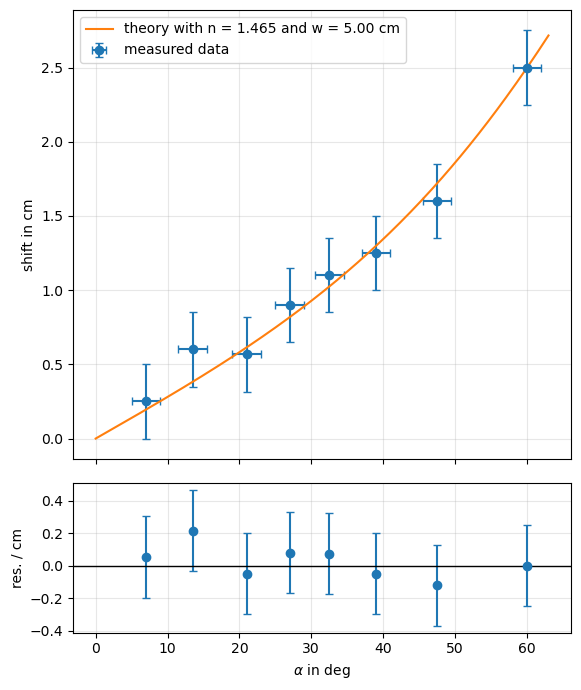

Predicted displacement for point 0: s = 2.498 +- 0.208 cm
Measured displacement for point 0: s_meas = 2.500 +- 0.250 cm
Difference: Delta s = 0.002 +- 0.325 cm


In [6]:
# Enter the measurements for the parallel displacement here.
alpha_shift = alpha  # angle of incidence in degrees
shift = np.array([2.5, 1.25, 0.567, 0.25, 0.6, 1.1, 1.6, 0.9])         # parallel displacement in cm
dshift = 0.25                # uncertainty of the displacement in cm

# Width of the prism / glass block in cm.
w = 5.0
dw = 0.15

# Index of the data point for the explicit prediction.
point_index = 0

# data verification
require_data(alpha_shift, shift)

if alpha_shift.shape != shift.shape:
    raise ValueError('alpha_shift and shift must have the same length.')
if w <= 0:
    raise ValueError('Enter the prism width in the variable w.')
if not (0 <= point_index < len(alpha_shift)):
    raise ValueError('point_index is outside the valid range.')

# fit curve
popt, pcov = curve_fit(
    lambda a, n: displacement_model(a, n, w),
    alpha_shift, shift,
    sigma=np.full_like(shift, dshift),
    absolute_sigma=True
)
print("previous n:", n_sin)
n_sin = popt[0]
print("new n:", n_sin)
dn_sin = np.sqrt(pcov[0, 0])
print("new dn:", dn_sin)

alpha_shift_fit = np.linspace(0, 1.05 * np.max(alpha_shift), 300)
shift_theory = displacement_model(alpha_shift_fit, n_sin, w)
shift_residuals = shift - displacement_model(alpha_shift, n_sin, w)

# plotting
fig, (ax, ax_res) = plt.subplots(2, 1, figsize=(6, 7), sharex=True, height_ratios=(3, 1))
ax.errorbar(alpha_shift, shift, xerr=dalpha, yerr=dshift, fmt='o', capsize=3, label='measured data')
ax.plot(alpha_shift_fit, shift_theory, label=f'theory with n = {n_sin:.3f} and w = {w:.2f} cm')
ax.set_ylabel('shift in cm')
ax.legend()
ax.grid(True, alpha=0.3)

ax_res.errorbar(alpha_shift, shift_residuals, yerr=dshift, fmt='o', capsize=3)
ax_res.axhline(0, color='black', linewidth=1)
ax_res.set_xlabel(r'$\alpha$ in deg')
ax_res.set_ylabel('res. / cm')
ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

alpha0 = alpha_shift[point_index]
alpha0_rad = np.deg2rad(alpha0)
beta0_rad = np.arcsin(np.clip(np.sin(alpha0_rad) / n_sin, -1, 1))
s0 = displacement_model(alpha0, n_sin, w)

# Numerical partial derivatives for Gaussian error propagation.
h_alpha = max(np.deg2rad(dalpha), 1e-6)
h_n = max(dn_sin, 1e-6)
h_w = max(dw, 1e-6)

def displacement_rad(alpha_rad, n, width_cm):
    beta_rad = np.arcsin(np.clip(np.sin(alpha_rad) / n, -1, 1))
    return width_cm * np.sin(alpha_rad - beta_rad) / np.cos(beta_rad)

ds_dalpha = (displacement_rad(alpha0_rad + h_alpha, n_sin, w) - displacement_rad(alpha0_rad - h_alpha, n_sin, w)) / (2 * h_alpha)
ds_dn = (displacement_rad(alpha0_rad, n_sin + h_n, w) - displacement_rad(alpha0_rad, n_sin - h_n, w)) / (2 * h_n)
ds_dw = (displacement_rad(alpha0_rad, n_sin, w + h_w) - displacement_rad(alpha0_rad, n_sin, w - h_w)) / (2 * h_w)

ds0 = np.sqrt((ds_dalpha * np.deg2rad(dalpha))**2 + (ds_dn * dn_sin)**2 + (ds_dw * dw)**2)
difference = shift[point_index] - s0
ddifference = np.sqrt(dshift**2 + ds0**2)

print(f'Predicted displacement for point {point_index}: s = {s0:.3f} +- {ds0:.3f} cm')
print(f'Measured displacement for point {point_index}: s_meas = {shift[point_index]:.3f} +- {dshift:.3f} cm')
print(f'Difference: Delta s = {difference:.3f} +- {ddifference:.3f} cm')

#### Discussion
As measuring the parallel displacement is quite hard and prone to errors, i.e. non-parallel line extensions and then measurement errors, we opted for a reasonably high uncertainty of 2.5mm.

With this, the graph of the function we derived above went through all of our measured data points (including error bars), indicating that the derivation is consistent with the data , and that tge data points were, within the uncertainty, consistently measured.

Examining the first point as an example, we only observe a small discrepancy to the expected/theoretical value, well with the previously mentioned high uncertainty.

#### Additional Task 1
The fitted graph can be seen above. The fitted refractive index is well within the error margin of the previously established refractive index.

#### Additional Task 2 - Fermat's Principle and Snell's Law

According to Fermat's principle, a light ray travels between two points along the path that requires the least time. We can use this idea to derive Snell's law for refraction at the boundary between two media.

Assume that the boundary between the two media is the $x$-axis. The first point is

$$
P_1 = (x_1,y_1)
$$

in medium 1, and the second point is

$$
P_2 = (x_2,y_2)
$$

in medium 2. The light ray crosses the boundary at some point

$$
P = (x,0),
$$

where $x$ is variable.

The distance from $P_1$ to $P$ is

$$
d_1 = \sqrt{(x-x_1)^2+y_1^2},
$$

and the distance from $P$ to $P_2$ is

$$
d_2 = \sqrt{(x-x_2)^2+y_2^2}.
$$

The total travel time is

$$
t(x) = \frac{d_1}{v_1} + \frac{d_2}{v_2}.
$$

$$
t(x)
=
\frac{\sqrt{(x-x_1)^2+y_1^2}}{v_1}
+
\frac{\sqrt{(x-x_2)^2+y_2^2}}{v_2}.
$$

To find the path of least time, we find the minimum of this function. First we derive $t(x)$:

$$
t'(x)
=
\frac{x-x_1}{v_1\sqrt{(x-x_1)^2+y_1^2}}
+
\frac{x-x_2}{v_2\sqrt{(x-x_2)^2+y_2^2}}.
$$

Using $d_1$ and $d_2$, this can be simplified to

$$
t'(x)
=
\frac{x-x_1}{v_1d_1}
+
\frac{x-x_2}{v_2d_2}.
$$

At the minimum travel time, the derivative must be zero:

$$
t'(x)=0.
$$

=>

$$
\frac{x-x_1}{v_1d_1}
=
-\frac{x-x_2}{v_2d_2}.
$$

Using trigonometry, we find that the fractions $\frac{x-x_1}/{d_1}$ and $\frac{x-x_2}{d_2}$ are equal to the sine of the angles made by the light ray with the normal to the boundary:
![trig](snell-trig.jpeg)

From this, we get

$$
\frac{\sin\theta_1}{v_1}
=
\frac{\sin\theta_2}{v_2}.
$$

Now we use the relationship between the speed of light in a medium and the refractive index:

$$
v = \frac{c}{n} \Rightarrow \frac{1}{v} = \frac{n}{c}.
$$

Plugging this into the previous equation gives

$$
\frac{n_1\sin\theta_1}{c}
=
\frac{n_2\sin\theta_2}{c}.
$$

$$
n_1\sin\theta_1
=
n_2\sin\theta_2.
$$

This is Snell's law. Therefore, Fermat's principle leads directly to Snell's law when a light ray passes from one medium into another.

source: idea of travel-time minimization inspired by ai, the rest self-derived.

#### Additional Task 3
Note: I unluckily did not have access to a Geodreieck or Zirkel while working on this exercise, please excuse the hand-drawn visualizations

See the below image for a derivation of the outgoing angle based on the incoming one:
![task-3](task-3.jpeg)
This holds for any rectangular prism, no matter the width and height, as long as the ray enters through one side and leaves through the other. Which side is longer or shorter also does not matter.

The deflection can be obtained by subtracting the above formula from the original angle, resulting in the following:
$$\Delta \theta(\theta) = \theta - 90° + \arcsin(n \cdot \sin(90° - \arcsin(\frac{\sin(\theta)}n)))$$

Going through some typical examples with our previously calculated refractive index, we find that none of them are defined in the real numbers (due to arcsin(>1)'s). Digging into this, we discover that for refractive indices (and in edge cases angles) that are too high (refractive indices $> \sqrt 2$), total internal refraction always occurs and the ray never actually exits through the intended side.

To get well-defined results, we used a refractive index of 1.3 for the examples below.

$\theta$ = 0° results in $\arcsin(1.3) - 90°$, which is undefined. This is expected, as at an incidence angle of 0° the ray cannot exit through a different face than it entered, thus rendering this formula inapplicable.

Incident angles below ~60° are also undefined, indicating total internal reflection.

| in | out | deflection | visualization |
| -- | -- | ---------- | - |
| 60 | ~14.2° | ~45.8° | ![a](60.jpeg) |
| 70 | ~26.1° | ~43.9° | ![a](70.jpeg) |
| 80 | ~31.9° | ~48.1° | ![a](80.jpeg) |

Visualizing these examples we notice that the sketch usesd to derive the formula in the first place is wrong; the outgoing ray's angle should be a good bit lower, i.e. closer to the prisms edge.

